Mergen der Bevölkerungsdaten und Unfalldaten

In [11]:
import pandas as pd
import numpy as np
import os

unfaelle = pd.read_excel(
    "Daten/merged_data.xlsx",
    sheet_name="merged"
)

unfaelle.head()

,Jahr,Gruppe,Unfälle_total,Unfälle_leicht,Unfälle_schwer,Unfälle_tödlich,Bevölkerung
0,2015,0-19,617,482,130,5,NaN
1,2015,20-90+,3014,2027,930,57,NaN
2,2016,0-19,595,464,126,5,NaN
3,2016,20-90+,2742,1870,835,37,NaN
4,2017,0-19,775,636,134,5,NaN


In [12]:
unfaelle.head()

,Jahr,Gruppe,Unfälle_total,Unfälle_leicht,Unfälle_schwer,Unfälle_tödlich,Bevölkerung
0,2015,0-19,617,482,130,5,NaN
1,2015,20-90+,3014,2027,930,57,NaN
2,2016,0-19,595,464,126,5,NaN
3,2016,20-90+,2742,1870,835,37,NaN
4,2017,0-19,775,636,134,5,NaN


In [14]:
bev_total = pd.read_excel(
    "Daten/merged_data.xlsx",
    sheet_name="Bevölkerung in Mio",
    skiprows=3,        # Überschrift überspringen
    usecols=[0, 1],    # Jahr + Bevölkerung
    names=["Jahr", "Bev_Mio"]
)

bev_total.head()

,Jahr,Bev_Mio
0,2006,7.51
1,2007,7.59
2,2008,7.70
3,2009,7.79
4,2010,7.86


In [15]:
alter = pd.read_excel(
    "Daten/merged_data.xlsx",
    sheet_name="Altersstruktur in %",
    skiprows=3,
    usecols=[0, 1],
    names=["Jahr", "Anteil_U20"]
)

# Prozent → Anteil
alter["Anteil_U20"] = alter["Anteil_U20"] / 100

alter.head()

,Jahr,Anteil_U20
0,2015,0.201
1,2016,0.201
2,2017,0.200
3,2018,0.200
4,2019,0.200


In [17]:
# Merge Gesamtbevölkerung + Altersanteil
bev = bev_total.merge(alter, on="Jahr", how="inner")

# Bevölkerung pro Gruppe
bev["Bev_0_19"] = bev["Bev_Mio"] * 1_000_000 * bev["Anteil_U20"]
bev["Bev_20_90"] = bev["Bev_Mio"] * 1_000_000 * (1 - bev["Anteil_U20"])

bev.head(10)

,Jahr,Bev_Mio,Anteil_U20,Bev_0_19,Bev_20_90
0,2015,8.33,0.201,1674330.0,6655670.0
1,2016,8.42,0.201,1692420.0,6727580.0
2,2017,8.48,0.200,1696000.0,6784000.0
3,2018,8.54,0.200,1708000.0,6832000.0
4,2019,8.61,0.200,1722000.0,6888000.0
5,2020,8.67,0.199,1725330.0,6944670.0
6,2021,8.74,0.199,1739260.0,7000740.0
7,2022,8.82,0.199,1755180.0,7064820.0
8,2023,8.96,0.200,1792000.0,7168000.0
9,2024,9.05,0.199,1800950.0,7249050.0


In [18]:
bev_long = bev.melt(
    id_vars="Jahr",
    value_vars=["Bev_0_19", "Bev_20_90"],
    var_name="Gruppe",
    value_name="Bevölkerung"
)

bev_long["Gruppe"] = bev_long["Gruppe"].map({
    "Bev_0_19": "0-19",
    "Bev_20_90": "20-90+"
})

bev_long.head()

,Jahr,Gruppe,Bevölkerung
0,2015,0-19,1674330.0
1,2016,0-19,1692420.0
2,2017,0-19,1696000.0
3,2018,0-19,1708000.0
4,2019,0-19,1722000.0


In [19]:
data_final = unfaelle.merge(
    bev_long,
    on=["Jahr", "Gruppe"],
    how="left"
)

data_final.head()

,Jahr,Gruppe,Unfälle_total,Unfälle_leicht,Unfälle_schwer,Unfälle_tödlich,Bevölkerung_x,Bevölkerung_y
0,2015,0-19,617,482,130,5,NaN,1674330.0
1,2015,20-90+,3014,2027,930,57,NaN,6655670.0
2,2016,0-19,595,464,126,5,NaN,1692420.0
3,2016,20-90+,2742,1870,835,37,NaN,6727580.0
4,2017,0-19,775,636,134,5,NaN,1696000.0


In [20]:
data_final["Bevölkerung"] = data_final["Bevölkerung_y"]

In [21]:
data_final = data_final.drop(columns=["Bevölkerung_x", "Bevölkerung_y"])

In [22]:
data_final.head()

,Jahr,Gruppe,Unfälle_total,Unfälle_leicht,Unfälle_schwer,Unfälle_tödlich,Bevölkerung
0,2015,0-19,617,482,130,5,1674330.0
1,2015,20-90+,3014,2027,930,57,6655670.0
2,2016,0-19,595,464,126,5,1692420.0
3,2016,20-90+,2742,1870,835,37,6727580.0
4,2017,0-19,775,636,134,5,1696000.0


In [23]:
data_final.to_excel(
    "Daten/merged_data.xlsx",
    sheet_name="merged",
    index=False
)

In [24]:
data_final.tail()

,Jahr,Gruppe,Unfälle_total,Unfälle_leicht,Unfälle_schwer,Unfälle_tödlich,Bevölkerung
15,2022,20-90+,2665,1823,810,32,7064820.0
16,2023,0-19,1052,776,265,11,1792000.0
17,2023,20-90+,2685,1792,854,39,7168000.0
18,2024,0-19,1089,831,247,11,1800950.0
19,2024,20-90+,2604,1788,781,35,7249050.0


In [27]:
# Unfallrate pro 1000 Personen (Total)
data_final["Unfallrate_1000"] = (
    data_final["Unfälle_total"] / data_final["Bevölkerung"] * 1000
)

In [28]:
data_final["Rate_schwer_1000"] = (
    data_final["Unfälle_schwer"] / data_final["Bevölkerung"] * 1000
)

data_final["Rate_toedlich_1000"] = (
    data_final["Unfälle_tödlich"] / data_final["Bevölkerung"] * 1000
)

In [29]:
data_final[[
    "Jahr",
    "Gruppe",
    "Unfälle_total",
    "Bevölkerung",
    "Unfallrate_1000"
]].head()

,Jahr,Gruppe,Unfälle_total,Bevölkerung,Unfallrate_1000
0,2015,0-19,617,1674330.0,0.368506
1,2015,20-90+,3014,6655670.0,0.452847
2,2016,0-19,595,1692420.0,0.351568
3,2016,20-90+,2742,6727580.0,0.407576
4,2017,0-19,775,1696000.0,0.456958


In [30]:
# Unfallraten pro 1'000 Personen
data_final["Rate_total_1000"]   = data_final["Unfälle_total"]   / data_final["Bevölkerung"] * 1000
data_final["Rate_leicht_1000"]  = data_final["Unfälle_leicht"]  / data_final["Bevölkerung"] * 1000
data_final["Rate_schwer_1000"]  = data_final["Unfälle_schwer"]  / data_final["Bevölkerung"] * 1000
data_final["Rate_toedlich_1000"] = data_final["Unfälle_tödlich"] / data_final["Bevölkerung"] * 1000

In [31]:
data_final[[
    "Jahr", "Gruppe",
    "Unfälle_total", "Rate_total_1000",
    "Rate_leicht_1000", "Rate_schwer_1000", "Rate_toedlich_1000"
]].head()

,Jahr,Gruppe,Unfälle_total,Rate_total_1000,Rate_leicht_1000,Rate_schwer_1000,Rate_toedlich_1000
0,2015,0-19,617,0.368506,0.287876,0.077643,0.002986
1,2015,20-90+,3014,0.452847,0.304552,0.139730,0.008564
2,2016,0-19,595,0.351568,0.274164,0.074450,0.002954
3,2016,20-90+,2742,0.407576,0.277960,0.124116,0.005500
4,2017,0-19,775,0.456958,0.375000,0.079009,0.002948


In [32]:
rate_cols = [
    "Rate_total_1000",
    "Rate_leicht_1000",
    "Rate_schwer_1000",
    "Rate_toedlich_1000"
]

data_final[rate_cols] = data_final[rate_cols].round(3)

In [33]:
from openpyxl import load_workbook
import pandas as pd

file_path = "Daten/merged_data.xlsx"

with pd.ExcelWriter(
    file_path,
    engine="openpyxl",
    mode="a",                # anhängen
    if_sheet_exists="replace"  # NUR dieses Sheet ersetzen
) as writer:
    data_final.to_excel(
        writer,
        sheet_name="merged_mit_Raten",
        index=False
    )




Explorative Datenanalyse





Zielvariablen:
Ufnfallrate_1000,
Rate_schwer,
Rate_tödlich

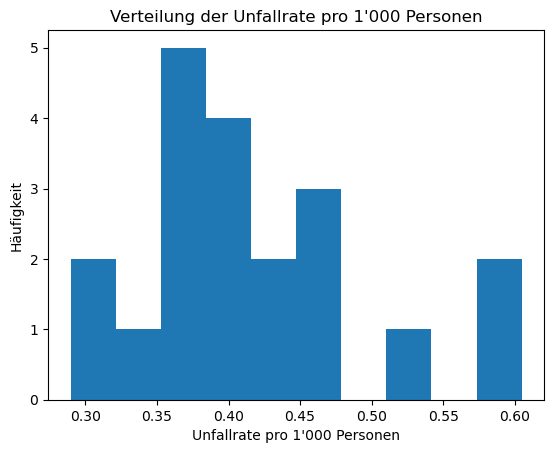

In [34]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(data_final["Unfallrate_1000"], bins=10)
plt.xlabel("Unfallrate pro 1'000 Personen")
plt.ylabel("Häufigkeit")
plt.title("Verteilung der Unfallrate pro 1'000 Personen")
plt.show()

Interpretation: Unfallrate pro 1000 personen liegt hauptsächlich zwischen 0.33-0.46.
Verteilung: Ist nicht symetrisch, sie ist leicht rechtsschief.
Normalverteilung: Nicht perfekt Normalverteilt, aber auch nicht extrem schief.
Ausreisser: Einzelne höhere Werte bei 0.55-0.6.
Bedeutung: Die meisten Beobachtungen konzentrieren sich um mittleren Bereich. Hohe Unfallrate selten aber existent.
Relativ stabile Unfallraten, deutet auf zeit- oder gruppenspezifische Effekte hin und nicht zufälliges Rauschen.

<Figure size 640x480 with 0 Axes>

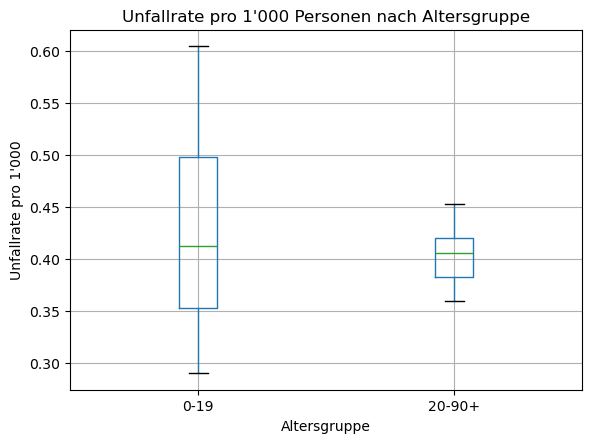

In [35]:
plt.figure()
data_final.boxplot(column="Unfallrate_1000", by="Gruppe")
plt.xlabel("Altersgruppe")
plt.ylabel("Unfallrate pro 1'000")
plt.title("Unfallrate pro 1'000 Personen nach Altersgruppe")
plt.suptitle("")  # entfernt automatische Zusatzüberschrift
plt.show()

Interpretation
Median: Gruppe 0-19 Jahre Median von ca. 0.41 Unfälle pro 1000 Personen.
Gruppe 20-90+ Jahre Median von ca. 40.5 Unfälle pro 1000 Personen. Beider Gruppen sehr ähnliche Medianwerte.
Streuung: Gruppe 0-19 Jahre hat Ratnwerte von 0.29-0.61, deutlich grössere Streung als Kontrollgruppe.
Gruppe 20-90+ Jahre hat Ratenwerte von 0.36-0.45. Relativ kompakte Verteilung.
Die Unfallrate der jüngeren Gruppe schwankt deutlich stärker über die Jahre als die der Kontrollgruppe.

<Figure size 640x480 with 0 Axes>

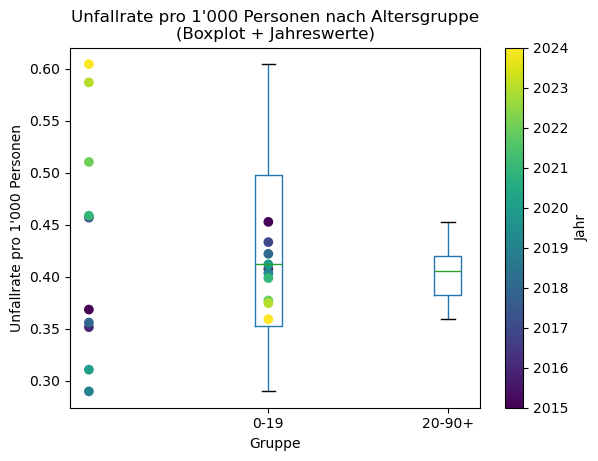

In [40]:
import matplotlib.pyplot as plt

plt.figure()

# Boxplot
data_final.boxplot(
    column="Unfallrate_1000",
    by="Gruppe",
    grid=False
)

# Punkte mit Jahr als Farbe
scatter = plt.scatter(
    x=data_final["Gruppe"],
    y=data_final["Unfallrate_1000"],
    c=data_final["Jahr"],
)

plt.colorbar(scatter, label="Jahr")

plt.suptitle("")
plt.title("Unfallrate pro 1'000 Personen nach Altersgruppe\n(Boxplot + Jahreswerte)")
plt.ylabel("Unfallrate pro 1'000 Personen")
plt.show()

Interpretation
Kontrolle der Ausreisser: Die höheren Unfallraten lassen sich bei der Altersgruppe 0-19 in den letzten Jahren einordnen.
Keine statistische ausreisser sondern ein zeitabhängiger Effekt.


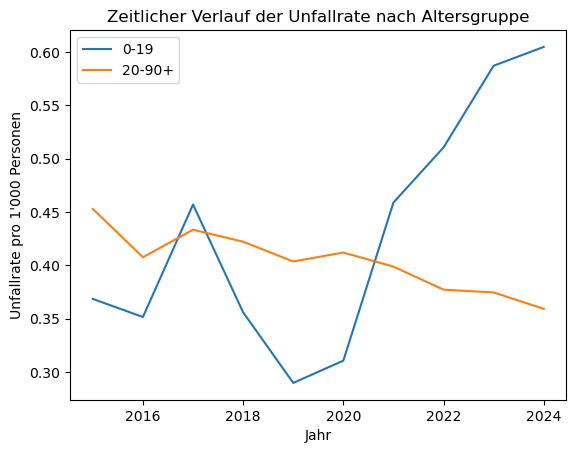

In [36]:
plt.figure()

for gruppe in data_final["Gruppe"].unique():
    subset = data_final[data_final["Gruppe"] == gruppe]
    plt.plot(subset["Jahr"], subset["Unfallrate_1000"], label=gruppe)

plt.xlabel("Jahr")
plt.ylabel("Unfallrate pro 1'000 Personen")
plt.title("Zeitlicher Verlauf der Unfallrate nach Altersgruppe")
plt.legend()
plt.show()

Interpretation
Gruppe 0-19: Zunächst schwanken die Raten zwischen 2015-2019. 2019 wird ein Minimum erreicht bei ca. 0.3.
Ab 2021 ist ein klarer kontinuierlicher Anstieg erkennbar. Höchstwerte bei 2023-2024 mit einem Maximum bei ca. 0.6.
Dies deutet auf strukturellen Bruch hin bzw. Trendwechsel hin. Die steigend hohen Werte ab 2021 sind keine Ausreisser sonder neue Niveaus.
Gruppe 20-90+: Die Unfallrate ist im gesamten Zeitraum duetlich stabiler. Es ist fast durchgehen einAbwärtstrend zu erkennen ohne Sprünge oder Extrempunkte.
Vergleich: Bis 2020 ist die Kontrollgruppe (20-90+) meist über der Gruppe der 0-19 jährigen. Ab 2021 kehrt sich dieses Verhältnis um. 
Es liegt ein altergruppenspezifischer Effekt vor, der Zeitlich klar begrenz ist (2021).

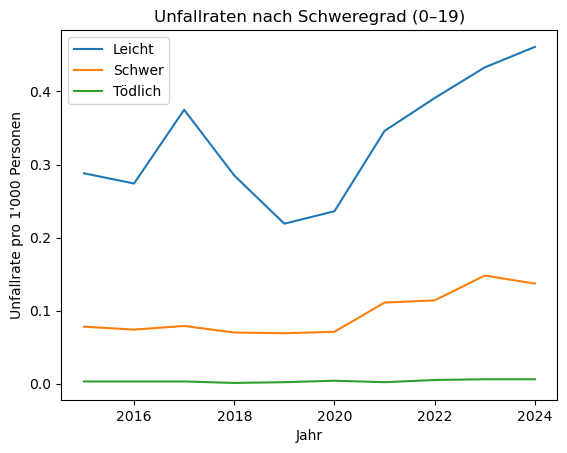

In [37]:
subset = data_final[data_final["Gruppe"] == "0-19"]

plt.figure()
plt.plot(subset["Jahr"], subset["Rate_leicht_1000"], label="Leicht")
plt.plot(subset["Jahr"], subset["Rate_schwer_1000"], label="Schwer")
plt.plot(subset["Jahr"], subset["Rate_toedlich_1000"], label="Tödlich")

plt.xlabel("Jahr")
plt.ylabel("Unfallrate pro 1'000 Personen")
plt.title("Unfallraten nach Schweregrad (0–19)")
plt.legend()
plt.show()

Interpretation
Leichte Unfälle: Die Unfallrate für leichte Unfälle ist im gesamten Zeitraum am höchsten. Bis 2019 ist ein leichter Rückgang erkennbar.
Ab 2021 folgt ein starker kontinuierlicher Anstieg. In 2023-2024 werden die Höchstwerte des Zeitraumes erreicht.
Schwere Unfälle: Die Unfallrate für schwere Unfälle ist duetlich tiefer als die leichten. Bis 2019 hält sie ein relativ stabiles Niveau.
Aber auch hier ab 2020/2021 folgt ein klarer Anstieg mit Höchstwerten im Jahr 2023
Tödliche Unfälle: Sind im gesamten Zeitraum sehr teif, es gibt keine Starken Ausschläge oder Trends. Leichte Schwankung bleiben aber nahe 0.